In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [10]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    names=columns
)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    print(
        column,
        "zero values:",
        (df[column] == 0).sum()
    )

Glucose zero values: 5
BloodPressure zero values: 35
SkinThickness zero values: 227
Insulin zero values: 374
BMI zero values: 11


In [12]:
df[zero_columns] = df[
    zero_columns
].replace(
    0,
    np.nan
)
print("Missing Values After Replacing Zeros:")
print(df.isnull().sum())

Missing Values After Replacing Zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [13]:
for column in zero_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
# check target distribution
print(
    df["Outcome"].value_counts()
)

Outcome
0    500
1    268
Name: count, dtype: int64


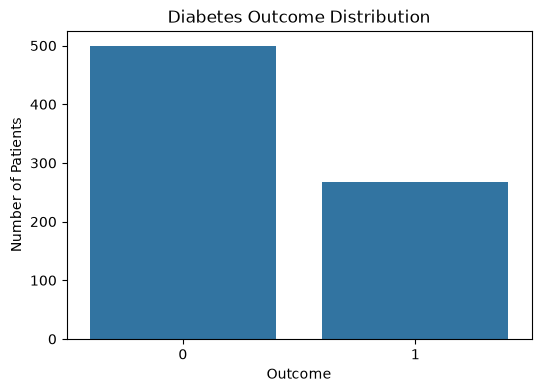

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.title(
    "Diabetes Outcome Distribution"
)

plt.xlabel(
    "Outcome"
)

plt.ylabel(
    "Number of Patients"
)

plt.show()

In [16]:
X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(
    "Training Features:",
    X_train.shape
)

print(
    "Testing Features:",
    X_test.shape
)

Training Features: (614, 8)
Testing Features: (154, 8)


In [19]:
# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [20]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            random_state=42
        )
}

In [21]:
results = []

predictions_dict = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    predictions_dict[name] = predictions

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

print("All five models trained successfully!")

All five models trained successfully!


In [22]:
results_df = pd.DataFrame(
    results
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,Decision Tree,0.681818,0.553191,0.481481,0.514851
2,Random Forest,0.779221,0.717391,0.611111,0.660000
3,KNN,0.753247,0.660000,0.611111,0.634615
4,SVM,0.740260,0.652174,0.555556,0.600000


In [23]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

results_display[metric_columns] = (
    results_display[metric_columns].round(4)
)

results_display


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455
1,Decision Tree,0.6818,0.5532,0.4815,0.5149
2,Random Forest,0.7792,0.7174,0.6111,0.6600
3,KNN,0.7532,0.6600,0.6111,0.6346
4,SVM,0.7403,0.6522,0.5556,0.6000


In [25]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(
    drop=True
)

results_display = results_df.copy()

results_display[metric_columns] = (
    results_display[metric_columns].round(4)
)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.7792,0.7174,0.6111,0.6600
1,KNN,0.7532,0.6600,0.6111,0.6346
2,SVM,0.7403,0.6522,0.5556,0.6000
3,Logistic Regression,0.7078,0.6000,0.5000,0.5455
4,Decision Tree,0.6818,0.5532,0.4815,0.5149


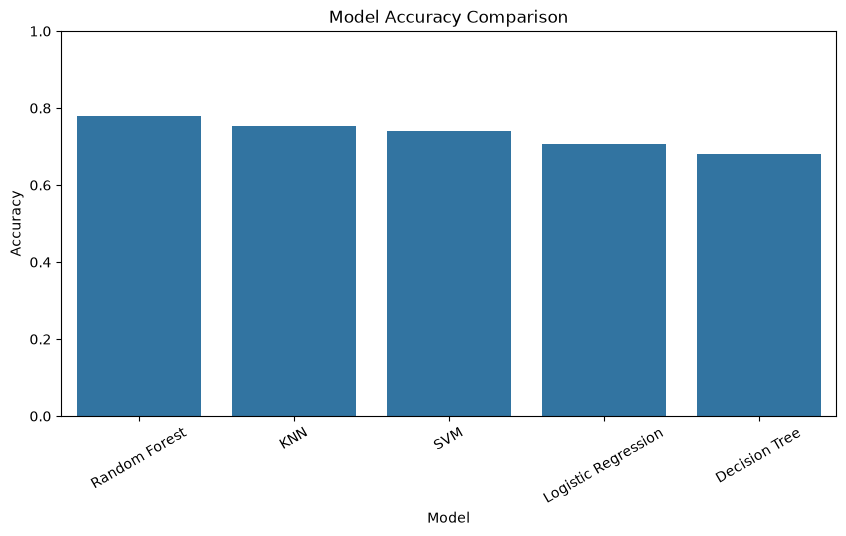

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.show()

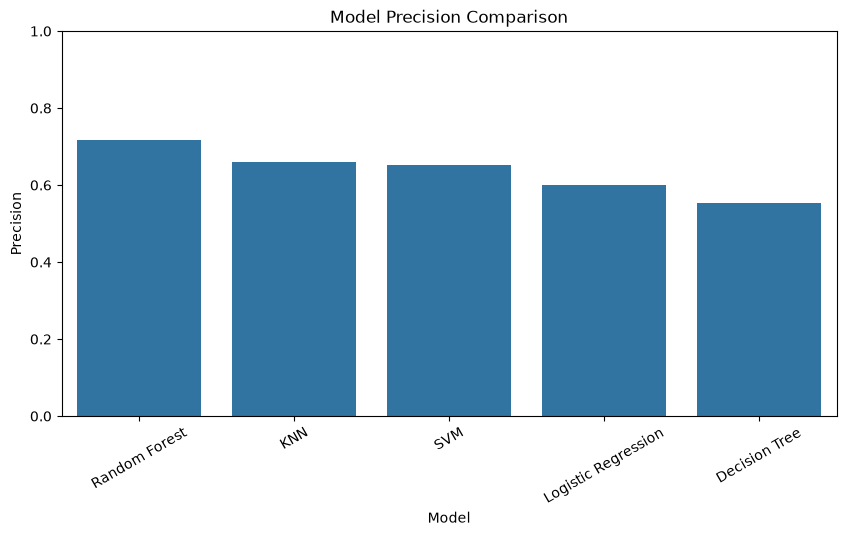

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.title(
    "Model Precision Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Precision"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.show()

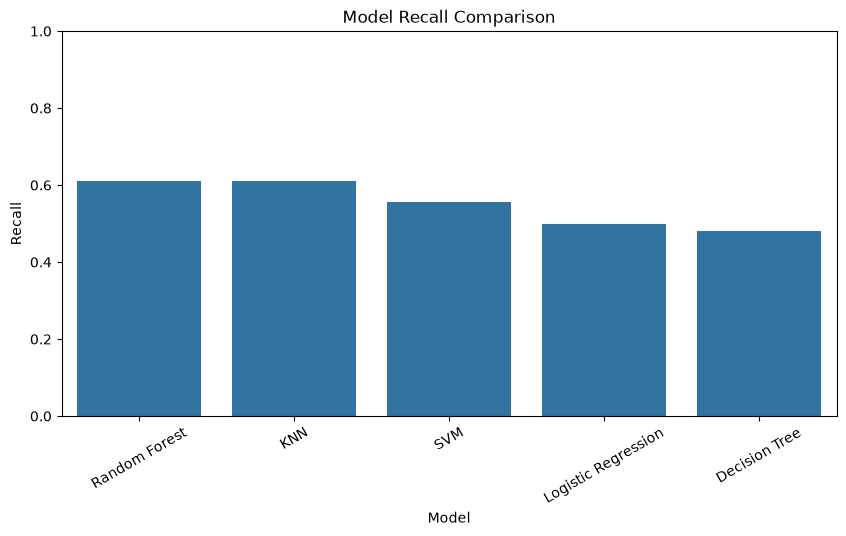

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.title(
    "Model Recall Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Recall"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.show()

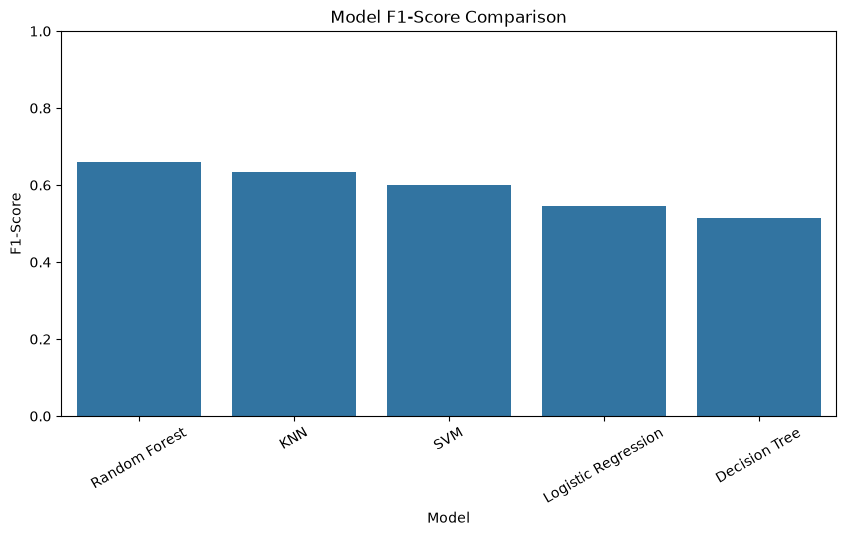

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-Score"
)

plt.title(
    "Model F1-Score Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "F1-Score"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.show()

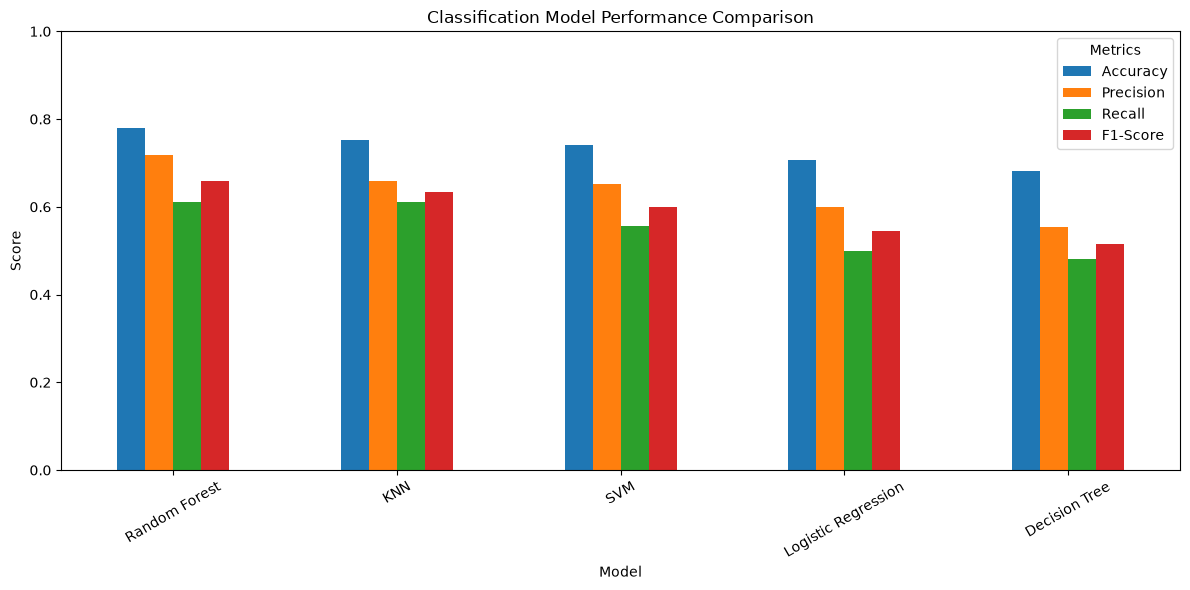

In [30]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

results_df.set_index(
    "Model"
)[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Classification Model Performance Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()

plt.show()

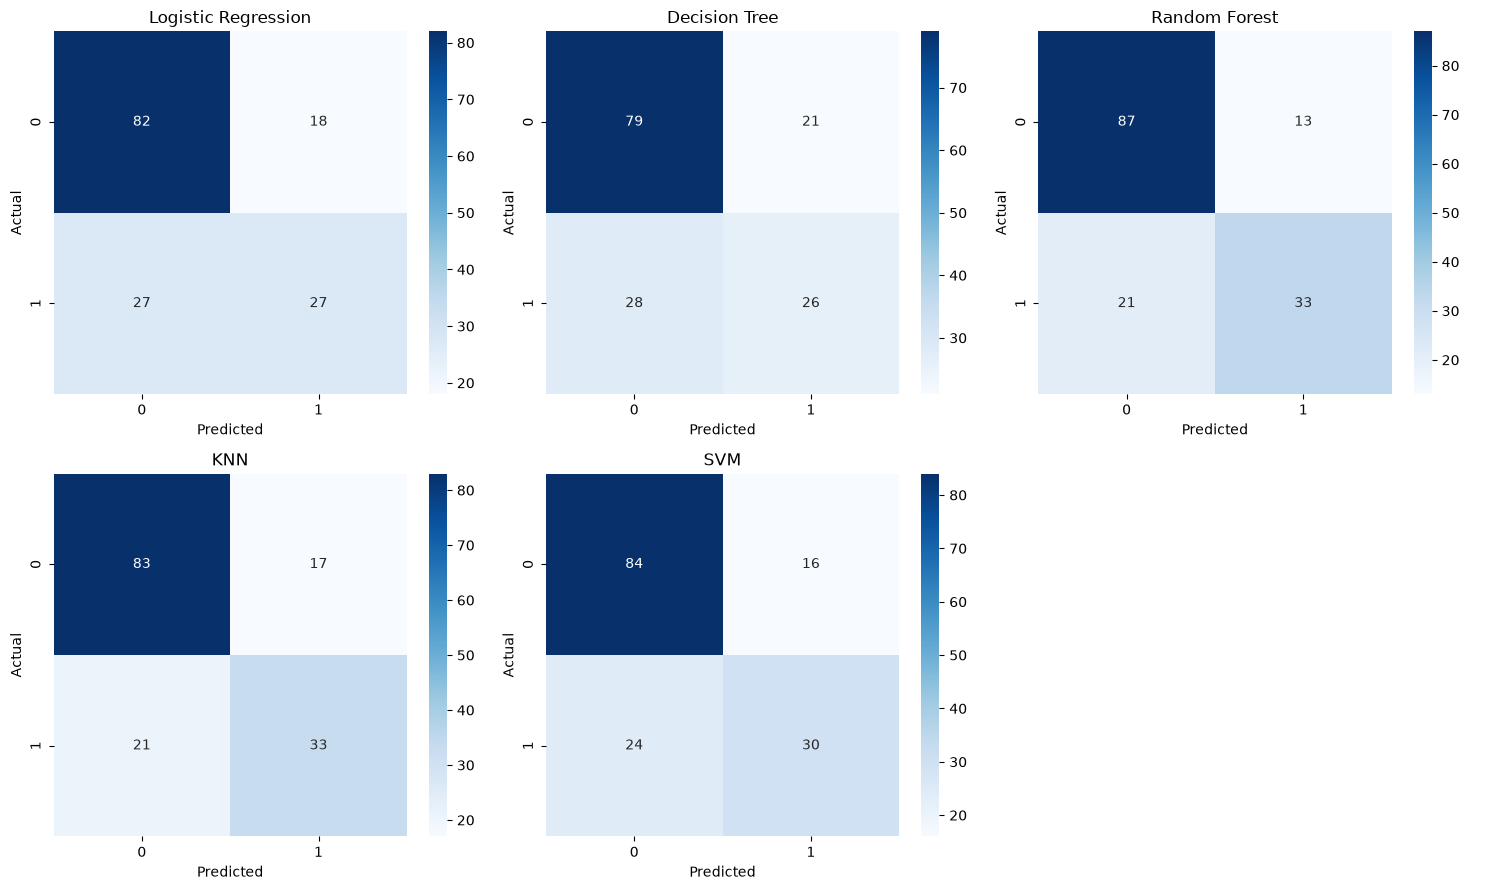

In [31]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, (name, predictions) in enumerate(
    predictions_dict.items()
):

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i]
    )

    axes[i].set_title(
        name
    )

    axes[i].set_xlabel(
        "Predicted"
    )

    axes[i].set_ylabel(
        "Actual"
    )

# Hide the unused sixth plot
axes[5].axis("off")

plt.tight_layout()

plt.show()

In [32]:
for name, predictions in predictions_dict.items():

    print("=" * 60)

    print(name)

    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Decision Tree
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154

Random Forest
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77   

In [33]:
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print(
    "Recommended Model:",
    best_model["Model"]
)

print(
    "Accuracy:",
    round(
        best_model["Accuracy"],
        4
    )
)

print(
    "Precision:",
    round(
        best_model["Precision"],
        4
    )
)

print(
    "Recall:",
    round(
        best_model["Recall"],
        4
    )
)

print(
    "F1-Score:",
    round(
        best_model["F1-Score"],
        4
    )
)

Recommended Model: Random Forest
Accuracy: 0.7792
Precision: 0.7174
Recall: 0.6111
F1-Score: 0.66


In [34]:
best_recall_model = results_df.loc[
    results_df["Recall"].idxmax()
]

print(
    "Highest Recall Model:",
    best_recall_model["Model"]
)

print(
    "Recall:",
    round(
        best_recall_model["Recall"],
        4
    )
)

Highest Recall Model: Random Forest
Recall: 0.6111


In [35]:
best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print(
    "Highest Accuracy Model:",
    best_accuracy_model["Model"]
)

print(
    "Accuracy:",
    round(
        best_accuracy_model["Accuracy"],
        4
    )
)

Highest Accuracy Model: Random Forest
Accuracy: 0.7792


In [36]:
final_ranking = results_df.copy()

final_ranking.index = (
    final_ranking.index + 1
)

final_ranking

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.779221,0.717391,0.611111,0.660000
2,KNN,0.753247,0.660000,0.611111,0.634615
3,SVM,0.740260,0.652174,0.555556,0.600000
4,Logistic Regression,0.707792,0.600000,0.500000,0.545455
5,Decision Tree,0.681818,0.553191,0.481481,0.514851


In [37]:
final_table = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].copy()

final_table[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
] = final_table[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].round(4)

final_table

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.7792,0.7174,0.6111,0.6600
1,KNN,0.7532,0.6600,0.6111,0.6346
2,SVM,0.7403,0.6522,0.5556,0.6000
3,Logistic Regression,0.7078,0.6000,0.5000,0.5455
4,Decision Tree,0.6818,0.5532,0.4815,0.5149


In [38]:
percentage_table = final_table.copy()

percentage_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

percentage_table[
    percentage_columns
] = (
    percentage_table[
        percentage_columns
    ] * 100
).round(2)

percentage_table

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,77.92,71.74,61.11,66.00
1,KNN,75.32,66.00,61.11,63.46
2,SVM,74.03,65.22,55.56,60.00
3,Logistic Regression,70.78,60.00,50.00,54.55
4,Decision Tree,68.18,55.32,48.15,51.49


In [39]:
best_name = best_model["Model"]

best_accuracy = best_model["Accuracy"]
best_precision = best_model["Precision"]
best_recall = best_model["Recall"]
best_f1 = best_model["F1-Score"]

print(
    "FINAL RECOMMENDATION"
)

print(
    "===================="
)

print(
    f"The recommended model is {best_name}."
)

print(
    f"Accuracy: {best_accuracy:.4f}"
)

print(
    f"Precision: {best_precision:.4f}"
)

print(
    f"Recall: {best_recall:.4f}"
)

print(
    f"F1-Score: {best_f1:.4f}"
)

FINAL RECOMMENDATION
The recommended model is Random Forest.
Accuracy: 0.7792
Precision: 0.7174
Recall: 0.6111
F1-Score: 0.6600


In [40]:
recommendation = f"""
Based on the experimental results, {best_name} achieved
the highest F1-score among the five evaluated classification
algorithms.

The model achieved an accuracy of {best_accuracy:.4f},
precision of {best_precision:.4f}, recall of {best_recall:.4f},
and F1-score of {best_f1:.4f}.

Therefore, {best_name} is recommended as the best-performing
model for this dataset based on the selected evaluation
criteria. Recall was also considered because correctly
identifying positive diabetes cases is an important
consideration in diabetes classification.
"""

print(recommendation)


Based on the experimental results, Random Forest achieved
the highest F1-score among the five evaluated classification
algorithms.

The model achieved an accuracy of 0.7792,
precision of 0.7174, recall of 0.6111,
and F1-score of 0.6600.

Therefore, Random Forest is recommended as the best-performing
model for this dataset based on the selected evaluation
criteria. Recall was also considered because correctly
identifying positive diabetes cases is an important
consideration in diabetes classification.

